In [73]:
from pathlib import Path
import sys
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import cvxpy as cp
import scipy.sparse as sp
import matplotlib.pyplot as plt

In [74]:
# If you are running with git clone
ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'nlpoptnet').is_dir() and (path / 'notebooks').is_dir()
)
SRC = ROOT / 'nlpoptnet' / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from nlpoptnet import NLPOptNet

print('ROOT =', ROOT)
print('SRC  =', SRC)

ROOT = /mnt/research/Hasan_Faruque/Students/Nath_Roy_Bimol/NLPOptNet
SRC  = /mnt/research/Hasan_Faruque/Students/Nath_Roy_Bimol/NLPOptNet/nlpoptnet/src


In [75]:
# if you have alread installed the package
from nlpoptnet import NLPOptNet

In [76]:
CONFIG = {
    'epochs': 10,
    'batch_size': 40,
    'learning_rate': 1e-3,
    'train_frac': 0.5,
    'hidden_size': 64,
    'hidden_layers': 2,
    'seed': 42,
    'alpha_consistency': 10.0,
    'cp_mode': 'fixed',
    'cp_iters': 300,
    'cp_tol': 1e-09,
    'safety': 0.95,
    'knorm_iters': 15,
    'knorm_seed': 42,
    'adjoint_iters': 20,
    'k_layer': 1,
    'use_ruiz': True,
    'ruiz_iters': 5,
    'dtype': 'float64',
    'print_every': 100,
    'device': 'auto',
    'verbose': True,
}

DATA_DIR = ROOT / 'notebooks' / 'generated' / 'qp_osqp_nlpoptnet'
DATA_DIR.mkdir(parents=True, exist_ok=True)


In [77]:
@dataclass
class ProblemSize:
    p: int = 50
    n: int = 100
    n_eq: int = 50
    n_ineq: int = 50
    n_train: int = 1000
    n_test: int = 1000

S = ProblemSize()
print(S)


ProblemSize(p=50, n=100, n_eq=50, n_ineq=50, n_train=1000, n_test=1000)


In [78]:
def sample_box(rng: np.random.Generator, p: int, low=-1.0, high=1.0):
    x_L = np.full(p, low, dtype=float)
    x_U = np.full(p, high, dtype=float)
    return x_L, x_U


def generate_sparse_A(
    rng: np.random.Generator,
    n_eq: int,
    n: int,
    density: float = 0.05,
):
    # Step 1: random sparse matrix with reproducible sparsity pattern and values
    A = sp.random(
        n_eq,
        n,
        density=density,
        format="csr",
        random_state=rng,  # controls sparsity pattern
        data_rvs=lambda k: rng.normal(0.0, 1.0, size=k),  # controls values
    )

    # Step 2: ensure no zero rows
    A = A.tolil()
    for i in range(n_eq):
        if A.rows[i] == []:
            j = rng.integers(0, n)
            A[i, j] = rng.normal()
    A = A.tocsr()

    # Step 3: row normalization
    row_norms = np.sqrt(A.power(2).sum(axis=1)).A1
    row_norms[row_norms == 0] = 1.0
    A = sp.diags(1.0 / row_norms) @ A

    # Step 4: simple full-row-rank heuristic
    if n_eq <= n:
        A = A + 1e-4 * sp.eye(n_eq, n, format="csr")

    return A


def build_problem_family(
    rng: np.random.Generator,
    n: int,
    p: int,
    n_eq: int,
    n_ineq: int,
    x_L: np.ndarray,
    x_U: np.ndarray,
):
    M = rng.standard_normal((n, n))
    delta = rng.uniform(1.2, 1.8, size=n)
    Q = (M.T @ M) / n + np.diag(delta)

    c = rng.uniform(0.5, 1.5, size=n)

    A = generate_sparse_A(rng, n_eq, n, density=0.1)
    row_scale = rng.uniform(0.8, 1.2, size=n_eq)
    A = sp.diags(row_scale) @ A

    y_c = rng.uniform(-0.5, 0.5, size=n)
    T = rng.uniform(-0.2, 0.2, size=(n, p))
    b = A @ y_c
    B = A @ T

    C = np.zeros((n_ineq, n))
    support = max(2, min(6, n // 8))
    for i in range(n_ineq):
        idx = rng.choice(n, size=support, replace=False)
        vals = rng.standard_normal(support)
        vals = vals / max(np.linalg.norm(vals), 1e-12)
        C[i, idx] = vals

    CT = C @ T
    midpoint = 0.5 * (x_L + x_U)
    radius = 0.5 * (x_U - x_L)
    max_aff = CT @ midpoint + np.sum(np.abs(CT) * radius[None, :], axis=1)
    d = C @ y_c + max_aff

    max_Tx = np.abs(T @ midpoint) + np.sum(np.abs(T) * radius[None, :], axis=1)
    r = 1.05 * np.max(max_Tx)
    l = y_c - r * np.ones(n)
    u = y_c + r * np.ones(n)
    L = T.copy()
    U = T.copy()

    return {
        "Q": Q,
        "c": c,
        "A": A,
        "b": b,
        "B": B,
        "C": C,
        "d": d,
        "l": l,
        "L": L,
        "u": u,
        "U": U,
        "x_L": x_L,
        "x_U": x_U,
        "y_c": y_c,
        "T": T,
    }


# -------------------------------
# Usage
# -------------------------------
seed = 0
rng = np.random.default_rng(seed)

x_L, x_U = sample_box(rng, S.p, low=-1.0, high=1.0)
problem = build_problem_family(rng, S.n, S.p, S.n_eq, S.n_ineq, x_L, x_U)

for k, v in problem.items():
    if isinstance(v, np.ndarray):
        print(f"{k:>4s}: {v.shape}")
    elif sp.issparse(v):
        print(f"{k:>4s}: {v.shape} [sparse]")

# print(problem['B'])

   Q: (100, 100)
   c: (100,)
   A: (50, 100) [sparse]
   b: (50,)
   B: (50, 50)
   C: (50, 100)
   d: (50,)
   l: (100,)
   L: (100, 50)
   u: (100,)
   U: (100, 50)
 x_L: (50,)
 x_U: (50,)
 y_c: (100,)
   T: (100, 50)


In [79]:
def build_cvxpy_problem(problem_data):
    Q = problem_data["Q"]
    c = problem_data["c"]
    A = problem_data["A"]
    b = problem_data["b"]
    B = problem_data["B"]
    C = problem_data["C"]
    d = problem_data["d"]
    l = problem_data["l"]
    L = problem_data["L"]
    u = problem_data["u"]
    U = problem_data["U"]

    n = Q.shape[0]
    p = B.shape[1]

    x_param = cp.Parameter(p)
    y_var = cp.Variable(n)

    objective = 0.5 * cp.quad_form(y_var, Q) + c @ y_var

    constraints = [
        A @ y_var == b + B @ x_param,
        C @ y_var <= d,
        y_var >= l + L @ x_param,
        y_var <= u + U @ x_param,
    ]

    prob = cp.Problem(cp.Minimize(objective), constraints)
    return prob, x_param, y_var

In [80]:
def solve_instance_cvxpy(
    problem_data,
    x_val,
    *,
    y_init=None,
    warm_start=False,
    eps_abs=1e-5,
    eps_rel=1e-5,
    max_iter=20000,
    polish=True,
):
    prob, x_param, y_var = build_cvxpy_problem(problem_data)

    x_param.value = np.asarray(x_val, dtype=float)
    y_var.value = None if y_init is None else np.asarray(y_init, dtype=float)

    t0 = time.perf_counter()
    val = prob.solve(
        solver=cp.OSQP,
        warm_start=warm_start,
        eps_abs=eps_abs,
        eps_rel=eps_rel,
        max_iter=max_iter,
        polish=polish,
        verbose=False,
    )
    elapsed = time.perf_counter() - t0

    return {
        "status": prob.status,
        "objective": val,
        "y": None if y_var.value is None else np.asarray(y_var.value).copy(),
        "time_wall": elapsed,
        "solve_time": getattr(prob.solver_stats, "solve_time", np.nan),
        "num_iters": getattr(prob.solver_stats, "num_iters", np.nan),
    }

In [81]:
x_mid = 0.5 * (x_L + x_U)
out = solve_instance_cvxpy(problem_data=problem,x_val=x_mid)
out

{'status': 'optimal',
 'objective': -6.722404209737164,
 'y': array([ 0.08852728, -0.04530152, -0.32380024,  0.38324058, -0.33842526,
        -0.03166074, -0.62682842, -0.43805104, -0.17561812, -0.62691688,
        -0.25279137, -0.18919553,  0.09671024, -0.06757252, -0.32389903,
        -0.2624789 , -0.62642554, -0.17173355, -0.21607723,  0.13562353,
        -0.45720587, -0.2705618 ,  0.64287442, -0.00263613, -0.2003359 ,
         0.29212099, -0.17482562, -0.6637476 , -0.39578125,  0.14509491,
         0.00155495, -0.48512841,  0.49090735, -0.06041963,  0.2841128 ,
        -0.35000069, -0.89707072,  0.12496171,  0.19097953, -0.48932645,
         0.12770906,  0.22630812, -0.07879103, -0.10421046, -0.33179272,
        -0.67459589, -0.18626272,  0.0889901 , -0.40239702, -0.77281343,
         0.51473901, -0.24805947, -0.46073523, -0.3383798 , -0.13795147,
        -0.28196166, -0.53829035, -0.32642784, -0.57684511, -0.63436371,
         0.35114167, -0.66434683, -0.65813244,  0.00317141, -0.

In [82]:
def sample_parameters(rng: np.random.Generator, n_samples: int, x_L, x_U):
    u = rng.uniform(size=(n_samples, len(x_L)))
    return x_L[None, :] + u * (x_U - x_L)[None, :]

X_all = sample_parameters(rng, S.n_train + S.n_test, x_L, x_U)

np.savez(
    DATA_DIR / 'problem.npz',
    Q=problem['Q'],
    c=problem['c'],
    A=problem['A'].toarray() if hasattr(problem['A'], "toarray") else problem['A'],
    b=problem['b'],
    B=problem['B'],
    C=problem['C'],
    d=problem['d'],
    l=problem['l'],
    L=problem['L'],
    u=problem['u'],
    U=problem['U'],
)

pd.DataFrame(X_all).to_csv(DATA_DIR / 'parameters.csv', index=False, header=False)

print('Saved files to:', DATA_DIR)
print('X_all shape =', X_all.shape)

Saved files to: /mnt/research/Hasan_Faruque/Students/Nath_Roy_Bimol/NLPOptNet/notebooks/generated/qp_osqp_nlpoptnet
X_all shape = (2000, 50)


In [83]:
model = NLPOptNet(config=CONFIG, type='qp', name='qp_osqp_nlpoptnet')

param_names = [f'x{i+1}' for i in range(S.p)]
var_names = [f'y{i+1}' for i in range(S.n)]

x = model.add_parameter(param_names)
y = model.add_variable(var_names)

model.extract(DATA_DIR / 'problem.npz')
model.objective(0.5 * model.quad(model.Q, y) + model.lin(model.c, y))
model.constraints.equality.add(
    model.lin(model.A, y) == model.b + model.lin(model.B, x),
)
model.constraints.inequality.add(
    model.lin(model.C, y) <= model.d,
)
model.constraints.box.add(
    var=y,
    lower=model.l + model.lin(model.L, x),
    upper=model.u + model.lin(model.U, x),
)
model.dataset(parameters=DATA_DIR / 'parameters.csv')
model.scale()
model.build()


Loaded problem constants: ['A', 'B', 'C', 'L', 'Q', 'U', 'b', 'c', 'd', 'l', 'u']
🤖 Model build successfully!


In [84]:
print("D_p =", model.scaling.D_p)
print("D_v =", model.scaling.D_v)
print("D_obj =", model.scaling.D_obj)
print("D_eq =", model.scaling.D_eq)
print("D_ineq =", model.scaling.D_ineq)

D_p = [0.99918313 0.9997741  0.99763529 0.99993485 0.99951455 0.99995427
 0.99881231 0.99982459 0.99964528 0.99981565 0.99991054 0.99980864
 0.99995622 0.99966838 0.99968631 0.99966852 0.99997353 0.99992974
 0.99971426 0.99913574 0.99973013 0.99981974 0.99962929 0.9999784
 0.99952346 0.99997257 0.99942554 0.99930923 0.99991959 0.99958421
 0.99992444 0.99968484 0.99952907 0.99985839 0.99956131 0.99996712
 0.99886868 0.99999302 0.99980778 0.99910484 0.99993983 0.99978119
 0.99965465 0.99973056 0.9997206  0.99964234 0.99918363 0.99837823
 0.99991391 0.99938869]
D_v = [7.96631213 8.06789354 8.0204369  7.9082551  7.88983889 7.67376843
 8.14617816 7.95309281 8.06891709 7.84092309 7.73189557 8.31137498
 7.87024866 8.07474416 7.6733286  8.09233777 8.03957453 7.70537383
 7.80600865 7.8935933  7.70937578 8.01560727 7.79105894 7.5382069
 7.88355847 7.91784882 8.06172525 7.97525429 8.08833352 7.9535679
 7.98740874 8.20575817 7.95065375 7.53525243 7.77530154 7.92999771
 7.95663174 7.91114734 7.8445

In [85]:
result = model.optimize()
run_dir = Path(result['output_dir'])

print('run_dir =', run_dir)
run_dir


▶️ Model training started! [2026-05-22 14:58:29]

       Epoch |                      Training                       |                     Validation                     
------------------------------------------------------------------------------------------------------------------------
             |         Loss          Obj           Eq         Ineq |         Loss          Obj           Eq         Ineq
     001/010 |   2.0356e+02   7.1318e+01   4.6882e-11   1.2463e-16 |   1.1882e+02   4.5085e+01   4.6240e-11   0.0000e+00
     010/010 |   1.9378e+01   1.1023e+01   4.1854e-11   0.0000e+00 |   1.9217e+01   1.1006e+01   3.8370e-11   0.0000e+00


⏱️ Model training time (wall time) = 26.6072 seconds
✅ Model training finished!
💾 Model saved!
📦 Postprocessing...
Meanwhile you can take a break and stay hydrated! 🧊💧😃
Done.

If you use this model in your research, please cite:
Nath Roy, Golder, & Hasan (2026) NLPOpt-Net: Nonlinear Parametric Optimization Network with Feasibility Guarantees

PosixPath('/mnt/research/Hasan_Faruque/Students/Nath_Roy_Bimol/NLPOptNet/notebooks/qp_osqp_nlpoptnet_20260522_145911')

In [86]:
model.summary()

📊 NLPOptNet :: Training Summary
------------------------------------------------------------
Model Name                        : qp_osqp_nlpoptnet
No. of Parameters                 : 50
No. of Variables                  : 100
No. of Equalities                 : 50
No. of Inequalities               : 50
No. of Train Samples              : 1000
No. of Validation Samples         : 1000
Maximum Constraint Violation      : 5.93581e-10
Training Time                     : 26.61 s
Est. JAX Single Inference Time    : 94.52 ms
Est. Native Single Inference Time : 2.37 ms
Est. JAX Batch Inference Time     : 148.41 ms
------------------------------------------------------------
Note: Inference time estimations are based on
microbenchmarking on the hardware used during
training and may vary across different hardware
and runtime conditions.


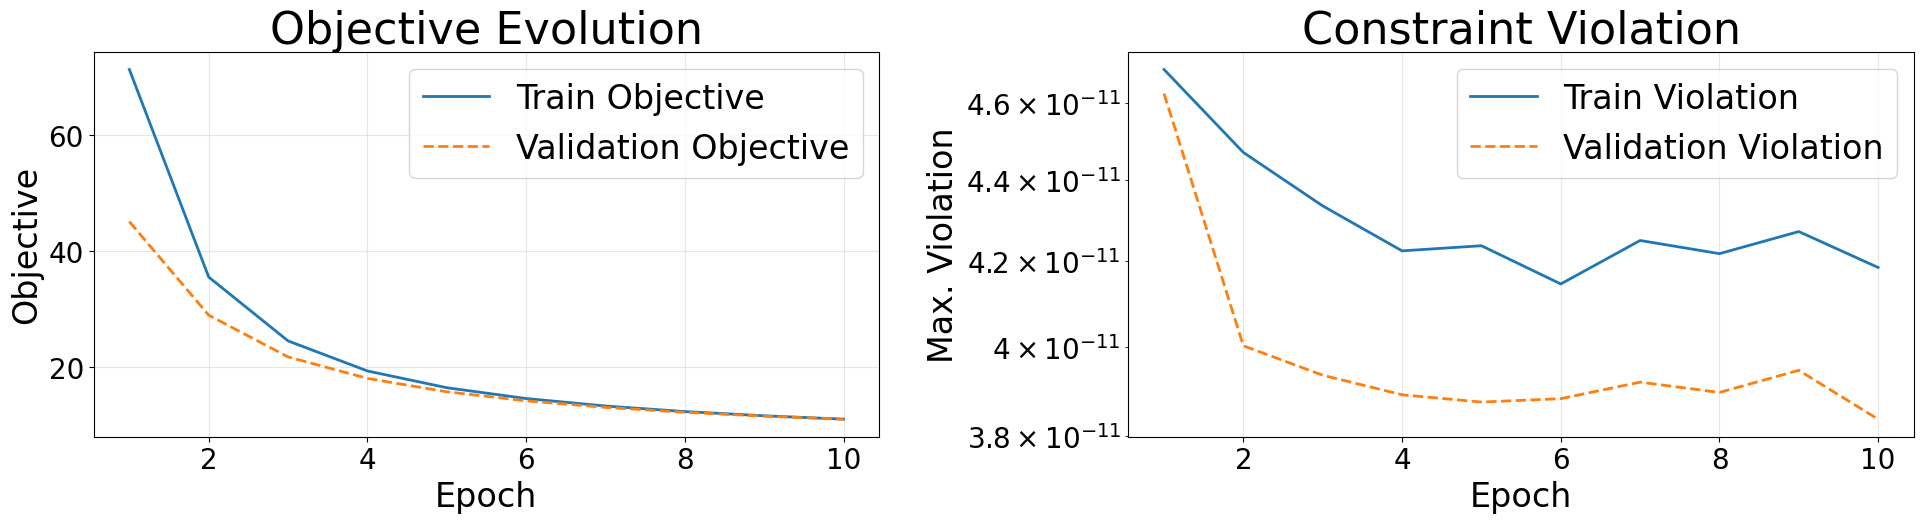

In [87]:
_ = model.plot_history(bg='white')

In [88]:
reloaded = NLPOptNet().load(run_dir / 'metadata.json')
sample_x = np.loadtxt(DATA_DIR / 'parameters.csv', delimiter=',', max_rows=1)

# sample_pred_native = np.asarray(reloaded.predict(sample_x, projection_backend='native')).reshape(-1)
# sample_pred_jax = np.asarray(reloaded.predict(sample_x, projection_backend='jax')).reshape(-1)

sample_pred_native = reloaded.predict(sample_x, projection_backend='native')
sample_pred_jax = reloaded.predict(sample_x, projection_backend='jax')

print('sample_x shape        =', sample_x.shape)
print('native pred shape     =', sample_pred_native.shape)
print('max native/jax diff   =', np.max(np.abs(sample_pred_native - sample_pred_jax)))



✅ Model Loaded Successfully
------------------------------------------------------------------------------------------------------------------------
Model Name   : qp_osqp_nlpoptnet
Location     : /mnt/research/Hasan_Faruque/Students/Nath_Roy_Bimol/NLPOptNet/notebooks/qp_osqp_nlpoptnet_20260522_145911
Time         : 2026-05-22 14:59:27

sample_x shape        = (50,)
native pred shape     = (100,)
max native/jax diff   = 1.469743216020447e-10


In [89]:
# --------------------------------------------------
# Settings
# --------------------------------------------------
num_samples = 200
warmup = 20
X_test = np.asarray(X_all[:num_samples], dtype=np.float64)


# --------------------------------------------------
# Objective helper
# --------------------------------------------------
def eval_objective(problem, x, y):
    Q = problem["Q"]
    c = problem["c"]
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    return 0.5 * y @ Q @ y + c @ y


# --------------------------------------------------
# Warmup (important for fair timing)
# --------------------------------------------------
print("Warming up backends...")

for xv in X_test[:warmup]:
    _ = reloaded.predict(xv, projection_backend="native")

for xv in X_test[:warmup]:
    _ = reloaded.predict(xv, projection_backend="jax")

# Optional OSQP warmup
for xv in X_test[:min(5, warmup)]:
    _ = solve_instance_cvxpy(problem, xv, y_init=None, warm_start=False)

print("Warmup done.")


# --------------------------------------------------
# Pass 1: isolated timing
# --------------------------------------------------
print("Running isolated timing benchmark...")

native_times = []
jax_times = []
osqp_times = []

for xv in X_test:
    # Native
    t0 = time.perf_counter()
    _ = reloaded.predict(xv, projection_backend="native")
    native_times.append(time.perf_counter() - t0)

for xv in X_test:
    # JAX
    t0 = time.perf_counter()
    _ = reloaded.predict(xv, projection_backend="jax")
    jax_times.append(time.perf_counter() - t0)

for xv in X_test:
    # OSQP baseline
    out_base = solve_instance_cvxpy(problem, xv, y_init=None, warm_start=False)
    osqp_times.append(out_base["solve_time"])

print("Timing benchmark done.")


# --------------------------------------------------
# Pass 2: prediction + objective benchmark
# --------------------------------------------------
print("Running objective / gap benchmark...")

records = []

for i, xv in enumerate(X_test):
    # OSQP solution and objective
    out_base = solve_instance_cvxpy(problem, xv, y_init=None, warm_start=False)
    y_opt = np.asarray(out_base["y"], dtype=np.float64).reshape(-1)
    obj_opt = float(out_base["objective"])

    # Native prediction and objective
    y_native = np.asarray(reloaded.predict(xv, projection_backend="native"), dtype=np.float64).reshape(-1)
    obj_native = float(eval_objective(problem, xv, y_native))

    # JAX prediction and objective
    y_jax = np.asarray(reloaded.predict(xv, projection_backend="jax"), dtype=np.float64).reshape(-1)
    obj_jax = float(eval_objective(problem, xv, y_jax))

    # Optimality gaps
    denom_native = max(abs(obj_native), 1e-8)
    denom_jax = max(abs(obj_jax), 1e-8)

    og_native = (obj_native - obj_opt) / denom_native * 100.0
    og_jax = (obj_jax - obj_opt) / denom_jax * 100.0

    records.append({
        "Sample No.": i + 1,

        # isolated timing results
        "Solve Time (OSQP) [s]": osqp_times[i],
        "Solve Time (NLPOpt-Net Native) [s]": native_times[i],
        "Solve Time (NLPOpt-Net JAX) [s]": jax_times[i],

        # milliseconds
        "Solve Time (OSQP) [ms]": osqp_times[i] * 1000.0,
        "Solve Time (NLPOpt-Net Native) [ms]": native_times[i] * 1000.0,
        "Solve Time (NLPOpt-Net JAX) [ms]": jax_times[i] * 1000.0,

        # objectives
        "Objective (OSQP)": obj_opt,
        "Objective (NLPOpt-Net Native)": obj_native,
        "Objective (NLPOpt-Net JAX)": obj_jax,

        # optimality gap
        "Optimality Gap (%) Native": og_native,
        "Optimality Gap (%) JAX": og_jax,

        # consistency check
        "Max |Native - JAX|": float(np.max(np.abs(y_native - y_jax))),
    })

print("Objective / gap benchmark done.")


# --------------------------------------------------
# Save detailed sample-wise results
# --------------------------------------------------
df = pd.DataFrame(records)
df.to_csv(DATA_DIR / "benchmark_results_detailed.csv", index=False)


# --------------------------------------------------
# Aggregate summary
# --------------------------------------------------
summary = {
    "num_samples": len(X_test),

    "avg_osqp_time_ms": float(np.mean(osqp_times) * 1000.0),
    "std_osqp_time_ms": float(np.std(osqp_times) * 1000.0),
    "median_osqp_time_ms": float(np.median(osqp_times) * 1000.0),

    "avg_native_time_ms": float(np.mean(native_times) * 1000.0),
    "std_native_time_ms": float(np.std(native_times) * 1000.0),
    "median_native_time_ms": float(np.median(native_times) * 1000.0),

    "avg_jax_time_ms": float(np.mean(jax_times) * 1000.0),
    "std_jax_time_ms": float(np.std(jax_times) * 1000.0),
    "median_jax_time_ms": float(np.median(jax_times) * 1000.0),

    "avg_obj_osqp": float(df["Objective (OSQP)"].mean()),
    "avg_obj_native": float(df["Objective (NLPOpt-Net Native)"].mean()),
    "avg_obj_jax": float(df["Objective (NLPOpt-Net JAX)"].mean()),

    "avg_og_native_pct": float(df["Optimality Gap (%) Native"].mean()),
    "avg_og_jax_pct": float(df["Optimality Gap (%) JAX"].mean()),

    "max_og_native_pct": float(df["Optimality Gap (%) Native"].max()),
    "max_og_jax_pct": float(df["Optimality Gap (%) JAX"].max()),

    "avg_max_abs_native_jax_diff": float(df["Max |Native - JAX|"].mean()),
    "max_abs_native_jax_diff": float(df["Max |Native - JAX|"].max()),
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(DATA_DIR / "benchmark_results_summary.csv", index=False)


# --------------------------------------------------
# Print concise report
# --------------------------------------------------
print("\nBenchmark Summary")
print("-" * 60)
print(f"Samples                    : {summary['num_samples']}")
print(f"OSQP avg time              : {summary['avg_osqp_time_ms']:.6f} ms")
print(f"Native avg time            : {summary['avg_native_time_ms']:.6f} ms")
print(f"JAX avg time               : {summary['avg_jax_time_ms']:.6f} ms")
print(f"Avg objective (OSQP)       : {summary['avg_obj_osqp']:.6e}")
print(f"Avg objective (Native)     : {summary['avg_obj_native']:.6e}")
print(f"Avg objective (JAX)        : {summary['avg_obj_jax']:.6e}")
print(f"Avg OG Native              : {summary['avg_og_native_pct']:.6f} %")
print(f"Avg OG JAX                 : {summary['avg_og_jax_pct']:.6f} %")
print(f"Max |Native - JAX|         : {summary['max_abs_native_jax_diff']:.6e}")
print("-" * 60)

df.head()

Warming up backends...
Warmup done.
Running isolated timing benchmark...
Timing benchmark done.
Running objective / gap benchmark...
Objective / gap benchmark done.

Benchmark Summary
------------------------------------------------------------
Samples                    : 200
OSQP avg time              : 1.683797 ms
Native avg time            : 2.598583 ms
JAX avg time               : 105.710121 ms
Avg objective (OSQP)       : 6.766464e+00
Avg objective (Native)     : 1.113451e+01
Avg objective (JAX)        : 1.113451e+01
Avg OG Native              : 59.664103 %
Avg OG JAX                 : 59.664103 %
Max |Native - JAX|         : 4.955247e-10
------------------------------------------------------------


,Sample No.,Solve Time (OSQP) [s],Solve Time (NLPOpt-Net Native) [s],Solve Time (NLPOpt-Net JAX) [s],Solve Time (OSQP) [ms],Solve Time (NLPOpt-Net Native) [ms],Solve Time (NLPOpt-Net JAX) [ms],Objective (OSQP),Objective (NLPOpt-Net Native),Objective (NLPOpt-Net JAX),Optimality Gap (%) Native,Optimality Gap (%) JAX,Max |Native - JAX|
0,1,0.001131,0.004208,0.094318,1.131036,4.207789,94.317744,3.192915,6.741081,6.741081,52.634966,52.634966,1.469743e-10
1,2,0.001577,0.003482,0.094974,1.576705,3.481705,94.973711,2.122508,5.019663,5.019663,57.716132,57.716132,1.153323e-10
2,3,0.001566,0.003528,0.094918,1.565846,3.528064,94.917805,11.923685,18.045934,18.045934,33.925920,33.925920,1.218682e-10
3,4,0.001575,0.003445,0.094631,1.575260,3.444996,94.631093,9.187139,12.770844,12.770844,28.061620,28.061620,2.175693e-10
4,5,0.001555,0.003457,0.094536,1.555201,3.456940,94.535591,6.182571,10.241255,10.241255,39.630727,39.630727,5.449929e-11
